# Practice lab, problem 3: the shuffle on Monday's sample

**Week 1, Thursday. The TA-led practice lab.** Monday's take-home sample, 24 orders you have already
counted, and a new question on it.

> **The client asks.** "Do Retail-Plus members really buy bigger baskets than Retail-Core, or is that
> just what we expect of a paid tier?" The head of Retail-Plus

Five lettered choices. Replace each `__TODOn__` with the line you choose; Run All stops at the first
placeholder until you do.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import random

ORDERS = kit.load_records("C2_W01_D04_monday_sample_STUDENT.py")


def mean(values):
    return sum(values) / len(values)


def shuffle_gaps(q1, q2, times, seed):
    random.seed(seed)
    pool = q1 + q2
    gaps = []
    for _ in range(times):
        random.shuffle(pool)
        gaps.append(mean(pool[:len(q1)]) - mean(pool[len(q1):]))
    return gaps


print(len(ORDERS), "orders in Monday's sample")

24 orders in Monday's sample


## Step 1. Every booked order in the two tiers

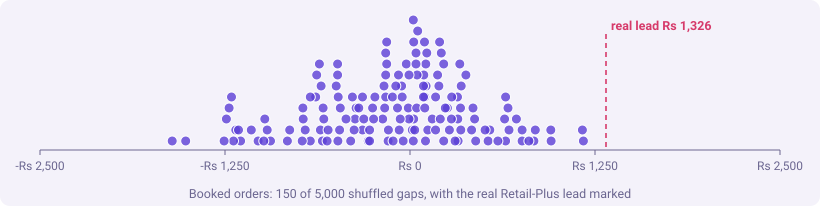

Retail-Plus 8 orders at Rs 3,420, Retail-Core 11 at Rs 2,093; lead Rs 1,326, share 0.002


In [2]:
# TODO 1. Which orders belong in a basket comparison between the two consumer tiers?
#   a) r["segment"] != "Student"
#   b) True
#   c) r["segment"] in ("Retail-Plus", "Retail-Core")
#   d) r["segment"] in ("Retail-Plus", "Retail-Core", "Business")
tiers = [r for r in ORDERS if r["segment"] in ("Retail-Plus", "Retail-Core")]
# TODO 2. How does each amount become a number the loop can average?
#   a) int(r["amount"])
#   b) r["amount"]
#   c) float(str(r["amount"]).replace(",", "")) or 0
#   d) len(str(r["amount"]))
plus = [int(r["amount"]) for r in tiers if r["segment"] == "Retail-Plus"]
core = [int(r["amount"]) for r in tiers if r["segment"] == "Retail-Core"]
real = mean(plus) - mean(core)
gaps = shuffle_gaps(plus, core, 5000, seed=2026)
# TODO 3. Which share is the p-value for a Retail-Plus lead at least as large?
#   a) sum(1 for g in gaps if g <= real) / len(gaps)
#   b) sum(1 for g in gaps if g >= real) / len(gaps)
#   c) real / max(gaps)
#   d) sum(1 for g in gaps if abs(g) >= abs(real) * 2) / len(gaps)
share_booked = sum(1 for g in gaps if g >= real) / len(gaps)
kit.strip(gaps[:150], markers=[("real lead", real, "bad")], lo=-2500, hi=2500,
          title="Booked orders: 150 of 5,000 shuffled gaps, with the real Retail-Plus lead marked")
print(f"Retail-Plus {len(plus)} orders at {kit.rupees(mean(plus))}, Retail-Core {len(core)} at {kit.rupees(mean(core))}; "
      f"lead {kit.rupees(real)}, share {share_booked:.3f}")
kit.check("19 booked orders sit in the two tiers", len(plus) + len(core) == 19)
kit.check("on booked orders the lead beats chance", share_booked < 0.01, f"{share_booked:.3f}")

**TODO 1 is c.** The question is about the two consumer tiers. a keeps Business, whose lakh-rupee orders would swamp any basket comparison; b keeps everyone; d names Business outright.

**TODO 2 is a.** Every amount in this file converts cleanly with int(), including the one stored as text, which is Monday's lesson. b leaves text in the list; c works here and hides a zero where a bad value would sit; d measures the length of the text.

**TODO 2 is a.** Every amount in this file converts cleanly with int(), including the one stored as text, which is Monday's lesson. b leaves text in the list; c works here and hides a zero where a bad value would sit; d measures the length of the text.

**TODO 3 is b.** A Retail-Plus lead at least as large as the real one is a shuffled gap at or above it. a is the other tail; c is a ratio with no count of worlds; d asks for a gap twice as large.

## Step 2. The same question on delivered orders only

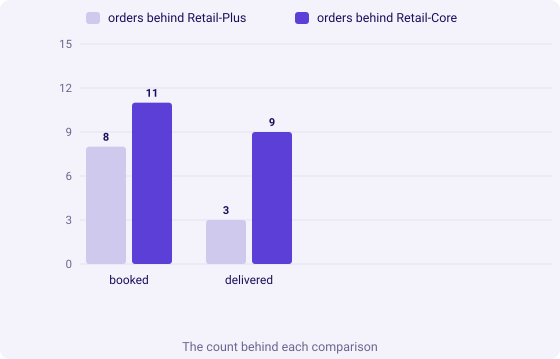

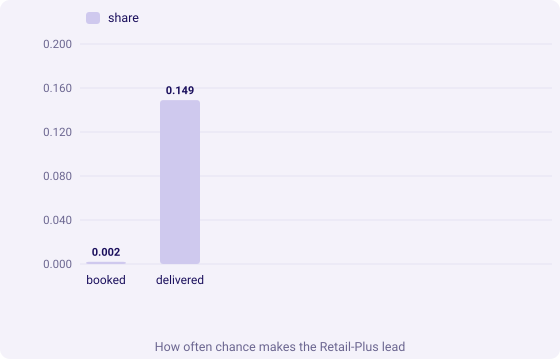

Not yet: on delivered orders the lead is Rs 671 and chance makes it about 15 times in 100, on only a handful of orders.


In [3]:
# TODO 4. Which filter keeps only the money kept?
#   a) r["status"] != "cancelled"
#   b) r["status"] == "returned" or r["status"] == "delivered"
#   c) r["amount"] != ""
#   d) r["status"] == "delivered"
kept = [r for r in tiers if r["status"] == "delivered"]
plus_d = [int(r["amount"]) for r in kept if r["segment"] == "Retail-Plus"]
core_d = [int(r["amount"]) for r in kept if r["segment"] == "Retail-Core"]
real_d = mean(plus_d) - mean(core_d)
gaps_d = shuffle_gaps(plus_d, core_d, 5000, seed=2026)
share_delivered = sum(1 for g in gaps_d if g >= real_d) / len(gaps_d)
kit.columns(["booked", "delivered"], [("orders behind Retail-Plus", [len(plus), len(plus_d)]),
                                      ("orders behind Retail-Core", [len(core), len(core_d)])],
            width=560, title="The count behind each comparison")
kit.columns(["booked", "delivered"], [("share", [round(share_booked, 3), round(share_delivered, 3)])],
            fmt=lambda v: f"{v:.3f}", width=560, title="How often chance makes the Retail-Plus lead")
# TODO 5. Which line reports the delivered result honestly?
#   a) "Retail-Plus baskets are bigger: the booked test says 0.002, so that settles it for every definition of sales we could use."
#   b) "Not yet: on delivered orders the lead is Rs 671 and chance makes it about 15 times in 100, on only a handful of orders."
#   c) "Retail-Plus baskets are smaller once returns are removed."
#   d) "The data is too dirty to use."
line = "Not yet: on delivered orders the lead is Rs 671 and chance makes it about 15 times in 100, on only a handful of orders."
print(line)
kit.check("delivered leaves Retail-Plus with only three orders", len(plus_d) == 3, f"{len(plus_d)}")
kit.check("on delivered orders chance makes the lead often", share_delivered > 0.10, f"{share_delivered:.3f}")
kit.check("the line says not yet", line.startswith('"Not yet') or line.startswith("Not yet"))

**TODO 4 is d.** Delivered is the money kept. a keeps returns; b says the same as a in more words; c keeps everything.

**TODO 5 is b.** It gives the delivered lead, the share and the count, and says not yet. a carries the booked result over to a definition it was never computed on; c claims a direction the data does not support; d refuses to answer a question the data can partly answer.

**What the problem teaches.** The booked comparison looks decisive, a Rs 1,326 lead that chance makes
2 times in 1,000, because four Retail-Plus orders that were later cancelled were large. On delivered
orders, the money kept, Retail-Plus has three orders, the lead is Rs 671, and chance makes it about
15 times in 100. The definition decided the verdict, and the count decided how far to trust it.

In [4]:
kit.check_summary()
print("Post the five letters in order; then problem 4 is on paper.")

Post the five letters in order; then problem 4 is on paper.
